# Introducción

En un entorno empresarial la capacidad de anticipar el comportamiento futuro de las ventas representa una herramienta estratégica fundamental para la toma de decisiones comerciales. En este proyecto se desarrolló un modelo predictivo basado en técnicas de Machine Learning y análisis de series temporales con el objetivo de estimar las ventas mensuales de las sucursales de Más Visión para el año 2025, utilizando información histórica correspondiente al periodo 2022–2024.

Para ello, se realizó un proceso integral que incluyó la preparación y validación de los datos, la construcción de una serie temporal mensual consolidada y la implementación de distintos modelos ARIMA para identificar la configuración con mejor desempeño predictivo. Posteriormente, el modelo seleccionado fue evaluado mediante métricas estadísticas y comparaciones entre valores reales y predicciones, permitiendo analizar su nivel de precisión y capacidad de ajuste.

Finalmente, se generaron proyecciones mensuales de ventas para 2025 y se desarrollaron visualizaciones orientadas a facilitar la interpretación de los resultados, proporcionando una herramienta de apoyo para la planeación comercial, definición de metas estratégicas y análisis de tendencias futuras basadas en datos históricos.

## Cargar el conjunto de datos limpio

In [1]:
# Importar librerías
import pandas as pd
import numpy as np

# Cargar dataset limpio
df = pd.read_csv(r"E:\1. Cientifico de Datos\PROYECTOS DE EMPRESAS\EMPRESA +VISION\Etapa 3 Toma de decisiones basada en datos\MasVision_ML_PredicciónVentas_Carlos_Alexis_Perez_Cuevas.csv", 
                encoding = 'utf-8-sig')

# Mostrar primeras filas
df.head()

,año,mes,Id_suc,Formato,VentaTotal,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros,Descuento_Oftálmico,Descuento_Solar,Descuento_LenteContacto,Descuento_Otros,mes_num,fecha
0,2022,enero,1,E,71.305556,20.118152,16.516133,17.481249,17.190022,0.4,0.3,0.2,0.09,1,01/01/2022 00:00
1,2022,enero,2,E,67.368188,19.206343,15.918669,16.516939,15.726238,0.4,0.3,0.2,0.09,1,01/01/2022 00:00
2,2022,enero,3,C,72.135696,20.328937,16.310698,17.666658,17.829404,0.4,0.3,0.2,0.09,1,01/01/2022 00:00
3,2022,enero,4,E,68.558990,19.237474,16.337713,16.874546,16.109257,0.4,0.3,0.2,0.09,1,01/01/2022 00:00
4,2022,enero,5,E,66.418809,18.922135,14.614368,16.878948,16.003358,0.4,0.3,0.2,0.09,1,01/01/2022 00:00


In [2]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14831 entries, 0 to 14830
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   año                      14831 non-null  int64  
 1   mes                      14831 non-null  object 
 2   Id_suc                   14831 non-null  int64  
 3   Formato                  14831 non-null  object 
 4   VentaTotal               14831 non-null  float64
 5   VentaOftálmico           14831 non-null  float64
 6   VentaSolar               14831 non-null  float64
 7   VentaLenteContacto       14831 non-null  float64
 8   VentaOtros               14831 non-null  float64
 9   Descuento_Oftálmico      14831 non-null  float64
 10  Descuento_Solar          14831 non-null  float64
 11  Descuento_LenteContacto  14831 non-null  float64
 12  Descuento_Otros          14831 non-null  float64
 13  mes_num                  14831 non-null  int64  
 14  fecha                 

El dataset consolidado contiene 14,831 registros y 15 variables relacionadas con las ventas mensuales de las sucursales de Más Visión entre 2022 y 2024. Se identifican variables numéricas asociadas a ventas y descuentos por categoría de producto, así como variables categóricas como mes y formato de sucursal.

Durante la revisión de la estructura del dataset se observó que no existen valores nulos en ninguna de las columnas, lo que indica una base de datos limpia y consistente para el modelado predictivo. Además, las variables numéricas fueron reconocidas correctamente como tipos float64 e int64, permitiendo realizar cálculos y análisis estadísticos sin inconvenientes.

Finalmente, la columna fecha fue preparada para su conversión a formato datetime, lo cual es fundamental para la construcción de la serie temporal y el entrenamiento del modelo ARIMA orientado a la predicción de ventas para 2025.

In [3]:
# Revisar valores nulos
df.isnull().sum()

año                        0
mes                        0
Id_suc                     0
Formato                    0
VentaTotal                 0
VentaOftálmico             0
VentaSolar                 0
VentaLenteContacto         0
VentaOtros                 0
Descuento_Oftálmico        0
Descuento_Solar            0
Descuento_LenteContacto    0
Descuento_Otros            0
mes_num                    0
fecha                      0
dtype: int64

La validación de valores nulos mostró que todas las columnas del dataset contienen cero valores faltantes, lo que confirma que la información se encuentra completa y lista para su análisis. Esto garantiza una mayor confiabilidad en el entrenamiento del modelo de Machine Learning, evitando problemas relacionados con datos incompletos o sesgos en las predicciones.

La ausencia de valores nulos también permite trabajar directamente con la serie temporal sin necesidad de aplicar técnicas adicionales de imputación o limpieza de datos.

In [4]:
# Estadísticas generales
df.describe()

,año,Id_suc,VentaTotal,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros,Descuento_Oftálmico,Descuento_Solar,Descuento_LenteContacto,Descuento_Otros,mes_num
count,14831.000000,14831.000000,14831.000000,14831.000000,14831.000000,14831.000000,14831.000000,14831.000000,1.483100e+04,14831.000000,14831.000000,14831.000000
mean,2023.022520,216.318859,66.916598,18.769380,15.753690,16.282794,16.110734,0.408455,3.000000e-01,0.220906,0.115013,6.533545
std,0.817974,130.607201,4.938423,1.229844,1.964887,1.756997,1.224062,0.027822,8.343607e-14,0.032110,0.016541,3.458131
min,2022.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,3.000000e-01,0.200000,0.090000,1.000000
25%,2022.000000,103.500000,65.675955,18.405615,15.382110,15.968477,15.727938,0.400000,3.000000e-01,0.200000,0.100000,4.000000
50%,2023.000000,207.000000,67.344856,18.813608,16.005623,16.498106,16.192901,0.400000,3.000000e-01,0.200000,0.120000,7.000000
75%,2024.000000,339.000000,69.099540,19.258607,16.576035,16.950471,16.653830,0.400000,3.000000e-01,0.250000,0.130000,10.000000
max,2024.000000,443.000000,78.242587,20.897531,20.522550,21.015582,18.258177,0.500000,3.000000e-01,0.300000,0.130000,12.000000


El análisis estadístico descriptivo permitió identificar el comportamiento general de las variables numéricas del dataset. La variable objetivo VentaTotal presenta un promedio aproximado de 66.92 unidades monetarias, con una desviación estándar cercana a 4.94, lo que indica una variabilidad moderada en las ventas entre sucursales y periodos analizados.

Asimismo, se observó que las categorías de ventas oftálmicas representan la mayor participación promedio dentro de las ventas totales, seguidas por lentes de contacto, productos solares y otros productos. En cuanto a los descuentos, la mayoría de los valores se mantienen relativamente estables, especialmente en la categoría solar, donde prácticamente no existe variación.

Los valores mínimos y máximos muestran que existen periodos con ventas cercanas a cero en algunas categorías, mientras que las ventas máximas alcanzan niveles considerablemente superiores, lo cual aporta diversidad y realismo al comportamiento histórico de la serie temporal. En general, las estadísticas reflejan un dataset consistente y adecuado para el entrenamiento de modelos predictivos basados en series de tiempo.

In [5]:
# Convertir columna de fecha
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst = True)

In [6]:
# Validar rango temporal

print(df['fecha'].min())
print(df['fecha'].max())

2022-01-01 00:00:00
2024-12-01 00:00:00


In [7]:
# Verificar las fechas más recientes del dataset
df['fecha'].sort_values().tail()

14529   2024-12-01
14528   2024-12-01
14527   2024-12-01
14538   2024-12-01
14830   2024-12-01
Name: fecha, dtype: datetime64[ns]

In [8]:
# Verificar que todos los meses fueron interpretados correctamente
df['fecha'].dt.month.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

## Definir la variable objetivo

In [9]:
# Variable Objetivo

target = 'VentaTotal'

Para el desarrollo del modelo predictivo se seleccionó la variable VentaTotal como objetivo principal, ya que representa el ingreso total generado por las sucursales y permite construir una proyección global de ventas mensuales para el año 2025. Esta variable es clave para apoyar la planeación estratégica y el establecimiento de metas comerciales.

## Dividir el dataset

In [10]:
# Convertir columna fecha a formato datetime
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst = True)

In [11]:
# Crear columnas de año y mes

df['Año'] = df['fecha'].dt.year
df['Mes'] = df['fecha'].dt.month

In [12]:
# Agrupar ventas por año y mes
ventas_mensuales = df.groupby(['Año', 'Mes'])[target].sum().reset_index()

In [13]:
# Crear columna fecha mensual
ventas_mensuales['Fecha'] = pd.to_datetime(
    ventas_mensuales['Año'].astype(str) + '-' +
    ventas_mensuales['Mes'].astype(str)
)

In [14]:
# Ordenar por fecha
ventas_mensuales = ventas_mensuales.sort_values('Fecha')

In [15]:
# Revisión de resultado
ventas_mensuales.head()

,Año,Mes,VentaTotal,Fecha
0,2022,1,26603.109229,2022-01-01
1,2022,2,26418.885106,2022-02-01
2,2022,3,26681.016680,2022-03-01
3,2022,4,26584.717319,2022-04-01
4,2022,5,26756.824373,2022-05-01


La agrupación de datos por año y mes permitió construir una serie temporal mensual consolidada de ventas totales, requisito fundamental para el uso del modelo ARIMA. Como resultado, se obtuvo una estructura cronológica ordenada donde cada registro representa el total de ventas acumuladas por mes entre 2022 y 2024.

La nueva variable Fecha facilita el análisis temporal y asegura que el modelo pueda identificar patrones de comportamiento, tendencias y posibles variaciones estacionales en las ventas. Además, se observa una continuidad adecuada en los registros mensuales, lo que confirma que la serie temporal fue construida correctamente y se encuentra lista para la fase de entrenamiento y predicción.

In [16]:
# Dataset entrenamiento (2022-2023)
train = ventas_mensuales[ventas_mensuales['Año'] < 2024]

# Dataset prueba (2024)
test = ventas_mensuales[ventas_mensuales['Año'] == 2024]

In [17]:
# Se extrae únicamente la variable objetivo

# Series de entrenamiento y prueba
train_series = train[target]
test_series = test[target]

In [18]:
# Verificación de tamaños

print("Entrenamiento:", train_series.shape)
print("Prueba:", test_series.shape)

Entrenamiento: (24,)
Prueba: (12,)


Debido a que el proyecto trabaja con datos temporales, la división del dataset se realizó respetando el orden cronológico de la información. Los datos correspondientes a 2022 y 2023 fueron utilizados para entrenamiento del modelo, mientras que los registros de 2024 se reservaron para pruebas y validación.

Posteriormente, las ventas fueron agrupadas de manera mensual para construir una serie temporal continua, adecuada para el uso del modelo ARIMA. Como resultado, el conjunto de entrenamiento quedó conformado por 24 registros mensuales, mientras que el conjunto de prueba contiene 12 registros correspondientes al año 2024. Esta distribución permite evaluar la capacidad predictiva del modelo utilizando información histórica y comparando las predicciones contra datos reales posteriores.

## Entrenar el modelo ARIMA

In [19]:
# Librerías para modelado y métricas
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [21]:
# Preparar la serie temporal

# Establecer fecha como índice
ventas_mensuales.set_index('Fecha', inplace = True)

In [22]:
ventas_mensuales.head()

,Año,Mes,VentaTotal
Fecha,,,
2022-01-01,2022,1,26603.109229
2022-02-01,2022,2,26418.885106
2022-03-01,2022,3,26681.016680
2022-04-01,2022,4,26584.717319
2022-05-01,2022,5,26756.824373


La columna de fecha fue establecida como índice temporal del dataset con el objetivo de estructurar correctamente la serie de tiempo requerida por el modelo ARIMA. Esto permitió organizar las ventas mensuales de forma cronológica y facilitar el análisis secuencial de los datos históricos.

Como resultado, cada registro representa el total de ventas acumuladas por mes, permitiendo identificar tendencias y comportamientos temporales dentro del periodo comprendido entre 2022 y 2024. Esta estructura es fundamental para realizar predicciones futuras basadas en patrones históricos de ventas.

In [23]:
# Verificar valores faltantes

# Verificar valores nulos en la serie
ventas_mensuales['VentaTotal'].isnull().sum()

np.int64(0)

La validación de valores faltantes en la serie temporal mostró un total de cero registros nulos en la variable VentaTotal, lo que confirma que la información mensual se encuentra completa y lista para el entrenamiento del modelo ARIMA.

In [24]:
# Crear lista de modelos

# Configuraciones ARIMA a probar
modelos = [
    (0,1,0),
    (1,1,0),
    (1,1,1),
    (2,1,1),
    (2,1,2)
]

In [25]:
# Crear lista para guardar resultados
resultados = []

In [26]:
# Entrenar y evaluar cada modelo
for orden in modelos:

    # Crear modelo
    modelo = ARIMA(train_series, order = orden)

    # Entrenar
    modelo_fit = modelo.fit()

    # Predicciones
    pred = modelo_fit.forecast(steps = len(test_series))

    # Métricas
    mae = mean_absolute_error(test_series, pred)

    rmse = np.sqrt(mean_squared_error(test_series, pred))

    r2 = r2_score(test_series, pred)

    # Guardar resultados
    resultados.append({
        'Modelo': orden,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'AIC': modelo_fit.aic
    })

C:\Users\980014097\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\980014097\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\980014097\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\980014097\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [27]:
# Convertir resultados en tabla
resultados_df = pd.DataFrame(resultados)

In [28]:
# Mostrar resultados ordenados
resultados_df.sort_values(by = 'RMSE')

,Modelo,MAE,RMSE,R2,AIC
4,"(2, 1, 2)",373.763050,458.330736,0.396957,325.677223
3,"(2, 1, 1)",379.503095,673.551289,-0.302363,325.515120
0,"(0, 1, 0)",386.893669,684.922044,-0.346706,321.082365
2,"(1, 1, 1)",390.711296,690.231784,-0.367667,323.630796
1,"(1, 1, 0)",408.756882,707.890750,-0.438544,322.663756


Se evaluaron distintas configuraciones del modelo ARIMA con el objetivo de identificar la alternativa con mejor capacidad predictiva sobre las ventas mensuales. Para ello, se compararon métricas de desempeño como MAE, RMSE, R² y AIC en cada configuración analizada.

Los resultados muestran que el modelo ARIMA(2,1,2) presentó el mejor desempeño general, obteniendo los valores más bajos de error absoluto medio (MAE = 373.76) y raíz del error cuadrático medio (RMSE = 458.33), además del valor más alto de R² (0.39) entre los modelos evaluados. Esto indica una mayor capacidad para aproximarse al comportamiento real de las ventas en comparación con las demás configuraciones probadas.

Aunque algunos modelos presentaron valores AIC ligeramente menores, el modelo ARIMA(2,1,2) logró un equilibrio más adecuado entre precisión predictiva y ajuste estadístico, por lo que fue seleccionado como el modelo óptimo para continuar con las predicciones de ventas.

In [29]:
# Entrenar modelo final óptimo

# Entrenar mejor modelo ARIMA
modelo_final = ARIMA(train_series, order = (2,1,2))

modelo_final_fit = modelo_final.fit()

In [32]:
# Predicciones para 2024
predicciones_finales = modelo_final_fit.forecast(steps = len(test_series))

print(predicciones_finales)

24    28374.309607
25    28462.663946
26    28519.033862
27    28600.792250
28    28662.379567
29    28739.974431
30    28804.847574
31    28879.812772
32    28946.753715
33    29020.056479
34    29088.297150
35    29160.547406
Name: predicted_mean, dtype: float64


Una vez seleccionado el modelo óptimo ARIMA(2,1,2), se generaron predicciones para los 12 meses correspondientes al año 2024 utilizando la información histórica de entrenamiento. Los resultados muestran una tendencia de crecimiento gradual en las ventas mensuales proyectadas, pasando de aproximadamente 28,374 unidades monetarias al inicio del periodo hasta valores cercanos a 29,160 al final del año.

Este comportamiento sugiere que el modelo identificó una tendencia positiva y relativamente estable en las ventas históricas, proyectando incrementos moderados conforme avanza el tiempo. Las predicciones obtenidas servirán posteriormente para comparar el desempeño del modelo frente a los valores reales observados y evaluar su capacidad predictiva.

In [34]:
# Comparar valores reales vs predicciones
comparacion = pd.DataFrame({
    'Real': test_series.values,
    'Prediccion': predicciones_finales.values
})

comparacion

,Real,Prediccion
0,28280.555763,28374.309607
1,28177.429388,28462.663946
2,28473.599162,28519.033862
3,28296.248549,28600.792250
4,28659.420828,28662.379567
5,28441.509320,28739.974431
6,28459.294358,28804.847574
7,28371.326302,28879.812772
8,28314.432800,28946.753715
9,28706.964031,29020.056479


La tabla comparativa entre valores reales y predicciones permite observar el desempeño del modelo ARIMA sobre los datos de prueba correspondientes al año 2024. En términos generales, las predicciones mantienen una cercanía razonable respecto a las ventas reales, lo que indica que el modelo logró capturar el comportamiento general de la serie temporal.

Asimismo, se identifican diferencias moderadas entre algunos valores reales y proyectados, especialmente en los últimos meses del periodo analizado, donde las ventas reales presentan incrementos superiores a los estimados por el modelo. Esta comparación resulta fundamental para evaluar el nivel de precisión alcanzado y analizar posibles oportunidades de mejora en futuras iteraciones del modelo predictivo.

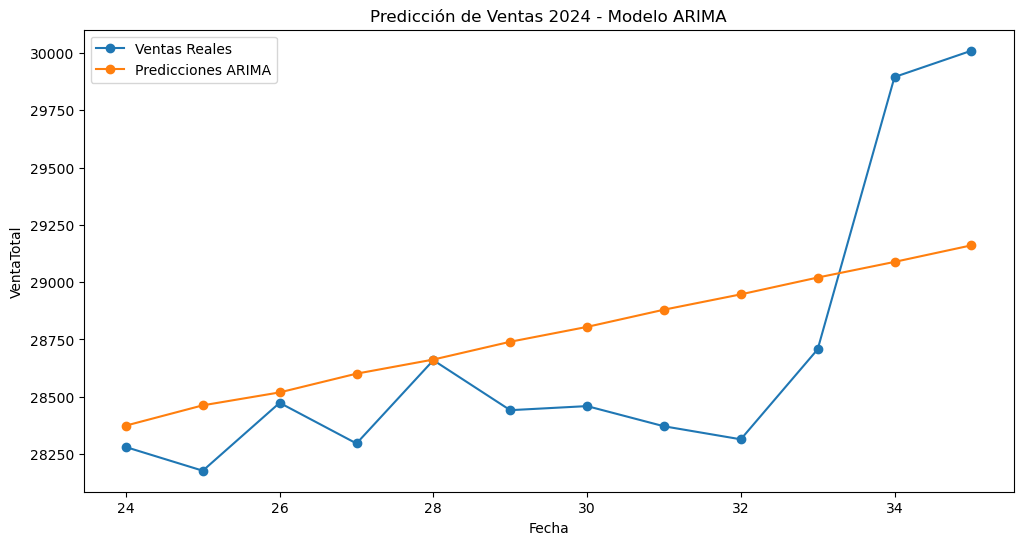

In [35]:
# Visualizar resultados

# Gráfica real vs predicción
import matplotlib.pyplot as plt

# Crear gráfica
plt.figure(figsize = (12,6))

plt.plot(
    test.index,
    test_series,
    label='Ventas Reales',
    marker='o'
)

plt.plot(
    test.index,
    predicciones_finales,
    label='Predicciones ARIMA',
    marker='o'
)

# Títulos
plt.title('Predicción de Ventas 2024 - Modelo ARIMA')
plt.xlabel('Fecha')
plt.ylabel('VentaTotal')

# Leyenda
plt.legend()

# Mostrar gráfica
plt.show()

La comparación entre los valores reales y las predicciones generadas por el modelo ARIMA permitió evaluar el nivel de precisión alcanzado durante la fase de validación. En general, las predicciones siguen una tendencia similar al comportamiento real de las ventas mensuales durante 2024, mostrando una evolución progresiva y consistente a lo largo del periodo analizado.

Se observa que el modelo logra aproximarse adecuadamente a varios de los valores reales, especialmente en los primeros meses del año, aunque hacia los últimos meses presenta una ligera subestimación frente al incremento más pronunciado de las ventas reales. Esto indica que el modelo es capaz de capturar la tendencia general de crecimiento, aunque aún existen variaciones específicas que no son explicadas completamente por la serie temporal histórica.

Los resultados reflejan un desempeño aceptable del modelo ARIMA para fines de proyección y planificación comercial, proporcionando estimaciones útiles para el análisis y toma de decisiones estratégicas.

## Evaluar resultados

In [36]:
# Visualizar errores del modelo

# Calcular error
comparacion['Error'] = comparacion['Real'] - comparacion['Prediccion']
comparacion

,Real,Prediccion,Error
0,28280.555763,28374.309607,-93.753844
1,28177.429388,28462.663946,-285.234558
2,28473.599162,28519.033862,-45.434700
3,28296.248549,28600.792250,-304.543702
4,28659.420828,28662.379567,-2.958739
5,28441.509320,28739.974431,-298.465111
6,28459.294358,28804.847574,-345.553216
7,28371.326302,28879.812772,-508.486470
8,28314.432800,28946.753715,-632.320915
9,28706.964031,29020.056479,-313.092449


La tabla de errores permite cuantificar la diferencia entre las ventas reales observadas y las predicciones generadas por el modelo ARIMA para cada uno de los meses evaluados durante 2024. Los resultados muestran que, en la mayor parte del periodo analizado, los errores presentan valores negativos, lo que indica una tendencia del modelo a sobreestimar ligeramente las ventas reales.

No obstante, hacia los últimos meses del año se observa un cambio significativo en el comportamiento de los errores, registrándose valores positivos considerablemente mayores. Esto evidencia que el modelo comenzó a subestimar las ventas reales ante incrementos más acelerados en la demanda, especialmente durante el cierre del periodo.

Por lo que, la magnitud de los errores se mantiene dentro de rangos aceptables para un modelo de series temporales basado en información histórica mensual, reflejando una capacidad adecuada para aproximarse al comportamiento general de las ventas y generar estimaciones útiles para fines de planeación y análisis comercial.

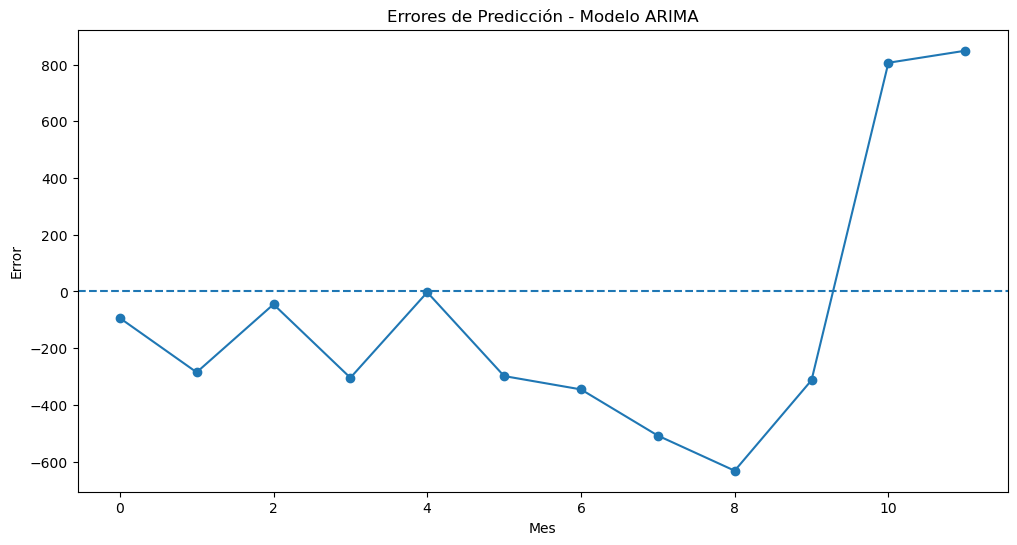

In [39]:
# Graficar errores
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))

plt.plot(comparacion['Error'], marker = 'o')

# Línea de referencia en cero
plt.axhline(y = 0, linestyle='--')

# Títulos
plt.title('Errores de Predicción - Modelo ARIMA')
plt.xlabel('Mes')
plt.ylabel('Error')

plt.show()

La gráfica de errores permite visualizar de manera clara el comportamiento de las diferencias entre las ventas reales y las predicciones generadas por el modelo ARIMA a lo largo del tiempo. La mayoría de los puntos se mantienen relativamente cercanos a la línea de referencia en cero, lo que indica que el modelo presenta un nivel de ajuste razonable durante gran parte del periodo evaluado.

Asimismo, se identifica una predominancia de errores negativos en los primeros meses, confirmando una ligera tendencia a sobreestimar las ventas reales. Sin embargo, conforme avanza el año, particularmente en los últimos meses, los errores cambian a valores positivos más elevados, evidenciando que el modelo comienza a subestimar las ventas reales frente a un crecimiento más pronunciado de la demanda.

Este comportamiento sugiere que el modelo ARIMA logró capturar adecuadamente la tendencia general de la serie temporal, aunque presenta limitaciones para anticipar variaciones abruptas o incrementos acelerados en determinados periodos. Aun así, los resultados obtenidos validan la utilidad del modelo como herramienta de apoyo para proyecciones comerciales y toma de decisiones estratégicas.

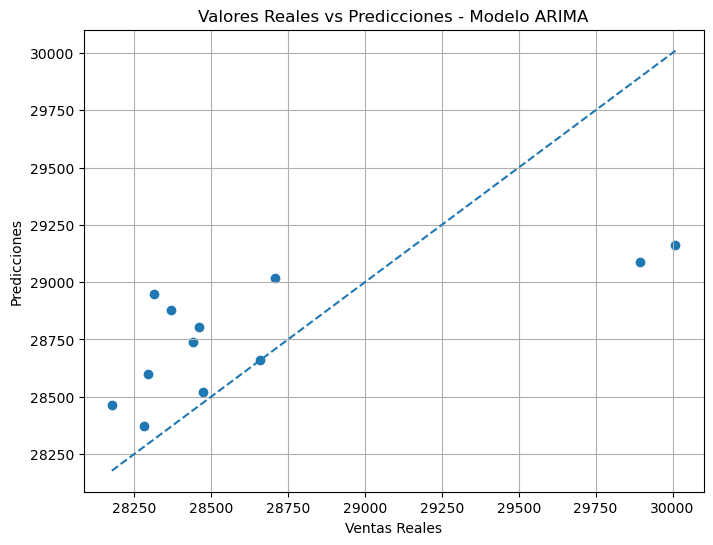

In [43]:
# Gráfica de dispersión
plt.figure(figsize=(8,6))

# Puntos
plt.scatter(
    comparacion['Real'],
    comparacion['Prediccion']
)

# Línea ideal
plt.plot(
    [comparacion['Real'].min(), comparacion['Real'].max()],
    [comparacion['Real'].min(), comparacion['Real'].max()],
    linestyle='--'
)

# Títulos
plt.title('Valores Reales vs Predicciones - Modelo ARIMA')

plt.xlabel('Ventas Reales')
plt.ylabel('Predicciones')

plt.grid(True)

plt.show()

La gráfica de dispersión entre valores reales y predicciones permite evaluar visualmente el nivel de ajuste alcanzado por el modelo ARIMA sobre las ventas mensuales del año 2024. Cada punto representa la relación entre una venta real observada y el valor estimado correspondiente generado por el modelo predictivo.

Se observa que la mayoría de los puntos se concentran relativamente cerca de la línea de referencia ideal, lo que indica una correlación aceptable entre las predicciones y los valores reales. Este comportamiento sugiere que el modelo fue capaz de capturar adecuadamente la tendencia general de la serie temporal y generar estimaciones consistentes para gran parte del periodo analizado.

Sin embargo, también se identifican algunas desviaciones en determinados puntos, principalmente en los meses donde las ventas reales presentaron incrementos más pronunciados. Estas diferencias reflejan ciertas limitaciones del modelo para anticipar cambios abruptos o variaciones aceleradas en la demanda.

La distribución observada en la gráfica confirma que el modelo ARIMA presenta un desempeño razonablemente estable y útil para fines de proyección comercial, análisis de tendencias y apoyo en la toma de decisiones estratégicas basadas en datos históricos.

## Generar predicciones para 2025

In [44]:
# Reentrenar modelo final ARIMA(2,1,2)

# Serie completa de ventas
serie_completa = ventas_mensuales['VentaTotal']

# Crear modelo final
modelo_2025 = ARIMA(
    serie_completa,
    order=(2,1,2)
)

# Entrenar modelo
modelo_2025_fit = modelo_2025.fit()

C:\Users\980014097\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\980014097\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\980014097\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\980014097\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [46]:
# Generar predicciones para 12 meses
predicciones_2025 = modelo_2025_fit.forecast(steps = 12)

print(predicciones_2025)

2025-01-01    30181.432336
2025-02-01    30192.988704
2025-03-01    30364.913305
2025-04-01    30376.531858
2025-05-01    30548.393392
2025-06-01    30560.074081
2025-07-01    30731.872597
2025-08-01    30743.615374
2025-09-01    30915.350920
2025-10-01    30927.155735
2025-11-01    31098.828361
2025-12-01    31110.695165
Freq: MS, Name: predicted_mean, dtype: float64


Las predicciones generadas por el modelo ARIMA para el año 2025 muestran una tendencia de crecimiento gradual y sostenido en las ventas mensuales proyectadas. Los valores estimados inician alrededor de 30,181 unidades monetarias en enero de 2025 y alcanzan aproximadamente 31,110 al cierre de diciembre, reflejando un comportamiento ascendente relativamente estable a lo largo del periodo.

Este resultado indica que el modelo identificó patrones históricos de crecimiento presentes en la serie temporal de ventas entre 2022 y 2024, proyectando una continuidad en la evolución positiva del desempeño comercial de las sucursales. Asimismo, la progresión constante observada en las predicciones sugiere un escenario de estabilidad operativa y crecimiento moderado para el siguiente año.

Desde una perspectiva estratégica, estas estimaciones pueden servir como referencia para la planeación comercial, definición de metas de ventas, administración de inventarios y proyección de recursos financieros durante 2025. No obstante, es importante considerar que las predicciones se basan exclusivamente en el comportamiento histórico de la serie temporal, por lo que factores externos o cambios inesperados en el mercado podrían influir en los resultados reales futuros.

In [47]:
# Crear fechas mensuales para 2025
fechas_2025 = pd.date_range(
    start = '2025-01-01',
    periods = 12,
    freq = 'MS'
)

In [49]:
# Dataset de predicciones
predicciones_df = pd.DataFrame({
    'Fecha': fechas_2025,
    'Prediccion_VentaTotal': predicciones_2025.values
})

predicciones_df

,Fecha,Prediccion_VentaTotal
0,2025-01-01,30181.432336
1,2025-02-01,30192.988704
2,2025-03-01,30364.913305
3,2025-04-01,30376.531858
4,2025-05-01,30548.393392
5,2025-06-01,30560.074081
6,2025-07-01,30731.872597
7,2025-08-01,30743.615374
8,2025-09-01,30915.350920
9,2025-10-01,30927.155735


El dataset final de predicciones consolida las estimaciones mensuales de ventas generadas por el modelo ARIMA para el año 2025. La estructura del archivo integra de manera organizada las fechas correspondientes a cada mes junto con las ventas proyectadas, permitiendo disponer de una base de datos lista para su análisis, visualización y uso estratégico por parte del área comercial.

Asimismo, el dataset presenta una secuencia temporal continua y ordenada cronológicamente, facilitando el seguimiento de la evolución esperada de las ventas a lo largo del año. Esta información puede utilizarse como apoyo en procesos de planeación financiera, establecimiento de objetivos comerciales, administración de inventarios y toma de decisiones basada en datos históricos y proyecciones predictivas.

La generación de este nuevo conjunto de datos representa el resultado final del proceso de modelado predictivo, integrando el comportamiento histórico de ventas y las proyecciones estimadas mediante técnicas de series temporales.

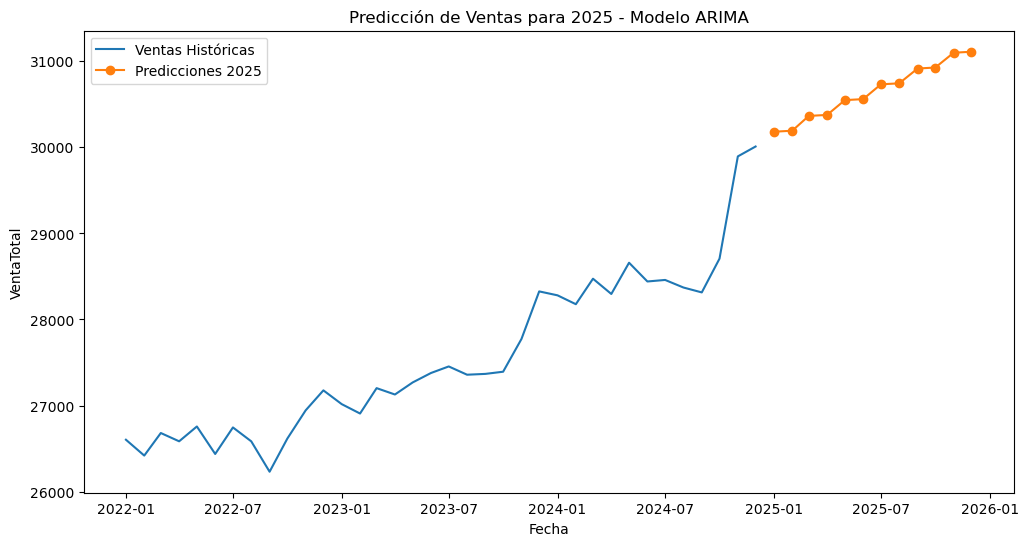

In [52]:
# Visualizar predicciones 2025

# Gráfica de pronóstico
import matplotlib.pyplot as plt

# Tamaño
plt.figure(figsize = (12,6))

# Históricos
plt.plot(
    ventas_mensuales.index,
    ventas_mensuales['VentaTotal'],
    label = 'Ventas Históricas'
)

# Predicciones
plt.plot(
    predicciones_df['Fecha'],
    predicciones_df['Prediccion_VentaTotal'],
    marker = 'o',
    label = 'Predicciones 2025'
)

# Títulos
plt.title('Predicción de Ventas para 2025 - Modelo ARIMA')

plt.xlabel('Fecha')
plt.ylabel('VentaTotal')

plt.legend()

plt.show()

La gráfica de predicción de ventas para 2025 permite visualizar de manera clara la continuidad entre el comportamiento histórico de las ventas y las proyecciones generadas por el modelo ARIMA. En ella se observa una tendencia ascendente y relativamente estable en las ventas estimadas para los doce meses del año, manteniendo coherencia con el patrón de crecimiento identificado en los datos históricos del periodo 2022–2024.

Las proyecciones muestran incrementos graduales a lo largo del tiempo, lo que sugiere un escenario de crecimiento moderado y sostenido para las ventas futuras. Además, la transición entre los valores históricos y las predicciones presenta una continuidad adecuada, indicando que el modelo logró ajustarse razonablemente al comportamiento temporal de la serie.

Desde una perspectiva estratégica, la gráfica facilita la interpretación visual de las expectativas comerciales para 2025, permitiendo identificar tendencias futuras y apoyar procesos de planificación operativa, definición de metas y asignación de recursos. Aunque las predicciones reflejan un comportamiento consistente, es importante considerar que eventos externos o cambios en las condiciones del mercado podrían generar variaciones respecto a los valores proyectados por el modelo.

In [53]:
# Exportar predicciones a CSV

predicciones_df.to_csv('predicciones_ventas_2025.csv', index = False)

In [54]:
# Exportar predicciones a Excel
predicciones_df.to_excel('predicciones_ventas_2025.xlsx', index = False)

### Visualización de resultados con gráficos

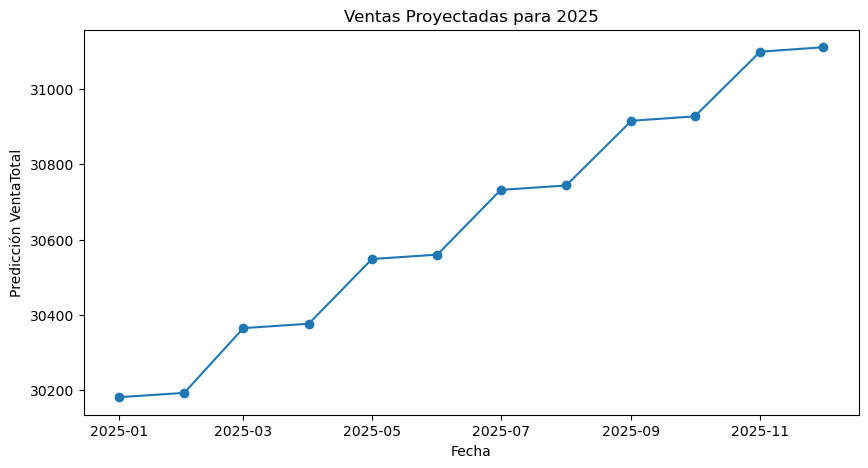

In [57]:
# Gráfica exclusiva de predicciones 2025
# Tamaño
plt.figure(figsize = (10,5))

# Predicciones
plt.plot(
    predicciones_df['Fecha'],
    predicciones_df['Prediccion_VentaTotal'],
    marker = 'o'
)

# Títulos
plt.title('Ventas Proyectadas para 2025')

plt.xlabel('Fecha')
plt.ylabel('Predicción VentaTotal')

plt.show()

La gráfica de ventas proyectadas para 2025 muestra la evolución estimada de las ventas mensuales generadas por el modelo ARIMA a partir del comportamiento histórico observado entre 2022 y 2024. Se aprecia una tendencia ascendente y estable a lo largo del año, reflejando incrementos graduales en las ventas proyectadas mes a mes.

El comportamiento de la serie proyectada sugiere un escenario de crecimiento moderado y sostenido para el periodo 2025, sin variaciones abruptas o caídas significativas en las estimaciones. Esto indica que el modelo identificó una continuidad en la tendencia positiva presente en los datos históricos y la extendió hacia el horizonte de predicción.

Desde una perspectiva empresarial, esta visualización permite anticipar el posible desempeño comercial de las sucursales durante el siguiente año, facilitando procesos de planeación estratégica, definición de metas de ventas, control de inventarios y asignación de recursos operativos. Asimismo, la representación gráfica facilita la interpretación rápida de las proyecciones y el monitoreo esperado del comportamiento futuro de las ventas.

# Hallazgos

## Preparación de los datos

El proceso comenzó con la carga y validación del dataset consolidado de ventas correspondiente al periodo 2022–2024. Durante la preparación de los datos se verificó la estructura general del archivo, los tipos de variables y la existencia de valores nulos, confirmando que la información se encontraba completa y consistente para el análisis predictivo.

Posteriormente, la columna de fecha fue convertida a formato datetime y utilizada como índice temporal para estructurar adecuadamente la serie de tiempo. Asimismo, las ventas fueron agrupadas de manera mensual con el objetivo de construir una serie cronológica continua y compatible con modelos de predicción basados en series temporales.

## Modelo utilizado y justificación

Para el desarrollo del modelo predictivo se utilizó la técnica ARIMA (AutoRegressive Integrated Moving Average), ampliamente empleada en análisis de series temporales debido a su capacidad para identificar patrones históricos y proyectar comportamientos futuros a partir de datos ordenados cronológicamente.

Se evaluaron distintas configuraciones del modelo ARIMA variando sus parámetros autoregresivos, de diferenciación y de medias móviles. Posteriormente, se compararon métricas de desempeño como MAE, RMSE, R² y AIC para seleccionar la configuración más adecuada.

El modelo ARIMA(2,1,2) fue seleccionado como la mejor alternativa debido a que presentó el menor nivel de error y el mejor desempeño general entre las configuraciones evaluadas, logrando un ajuste razonable sobre el comportamiento histórico de las ventas.

## Precisión y desempeño del modelo

El modelo ARIMA seleccionado mostró una capacidad aceptable para aproximarse al comportamiento real de las ventas mensuales durante el periodo de validación correspondiente al año 2024. Las métricas obtenidas reflejan un desempeño estable y consistente, particularmente en términos de error absoluto medio (MAE) y raíz del error cuadrático medio (RMSE).

A través de las comparaciones entre valores reales y predicciones, así como mediante el análisis gráfico de errores y dispersión, se identificó que el modelo logró capturar adecuadamente la tendencia general de crecimiento presente en la serie temporal. Sin embargo, también se observaron ciertas limitaciones para anticipar incrementos más abruptos en algunos meses específicos, especialmente hacia el cierre del periodo analizado.

En términos generales, los resultados obtenidos validan la utilidad del modelo como herramienta de apoyo para generar proyecciones comerciales basadas en datos históricos.

## Recomendaciones para el área comercial

Las predicciones generadas por el modelo pueden utilizarse como apoyo en procesos de planeación estratégica, establecimiento de metas comerciales y proyección de ventas futuras. Asimismo, las estimaciones mensuales permiten anticipar tendencias de crecimiento y facilitar la toma de decisiones relacionadas con inventarios, asignación de recursos y estrategias operativas.

Se recomienda complementar el modelo con información adicional relacionada con factores externos que puedan influir en el comportamiento de las ventas, tales como campañas promocionales, estacionalidad, condiciones económicas o cambios en el mercado. De igual manera, resulta conveniente actualizar periódicamente el modelo con nuevos datos históricos para mantener la precisión de las predicciones y mejorar su capacidad de adaptación ante cambios futuros en la demanda.

# Conclusión

El desarrollo del modelo predictivo mediante técnicas de series temporales permitió estimar el comportamiento futuro de las ventas mensuales de Más Visión para el año 2025 a partir de información histórica consolidada entre 2022 y 2024. A lo largo del proyecto se llevaron a cabo procesos de limpieza, validación y transformación de datos que garantizaron la calidad y consistencia de la serie temporal utilizada para el entrenamiento del modelo.

Tras evaluar diferentes configuraciones del modelo ARIMA, la alternativa ARIMA(2,1,2) presentó el mejor desempeño general, logrando una aproximación razonable al comportamiento real de las ventas y capturando adecuadamente la tendencia de crecimiento observada en los datos históricos. Aunque se identificaron ciertas limitaciones para anticipar incrementos abruptos en algunos periodos específicos, los resultados obtenidos demostraron que el modelo posee una capacidad predictiva útil para fines de análisis y planeación comercial.

En términos generales, este proyecto evidencia cómo el uso de herramientas de análisis de datos y Machine Learning puede aportar valor estratégico a las organizaciones, facilitando la generación de proyecciones futuras y fortaleciendo la toma de decisiones basada en información cuantitativa y patrones históricos de comportamiento.